# Decision Tree Classifier
## IBM HR Analytics Employee Attrition Prediction
### ML Assignment — SLIIT

**Student ID:** IT221091942  
**Student Name:** Wijesinghe L P D B  
**Algorithm:** Decision Tree Classifier  
**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Dataset URL:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset  

## 1: Import Libraries

In [72]:
# Data handling
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Decision Tree model
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


## 2: Load the Dataset

In [73]:
# Load the dataset — make sure the CSV is in the same folder as this notebook
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [74]:
# Check for missing values
print("Missing values:", df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes.value_counts())

Missing values: 0

Data types:
int64     26
object     9
Name: count, dtype: int64


Target Variable Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Percentage:
Attrition
No     83.88%
Yes    16.12%
Name: proportion, dtype: object


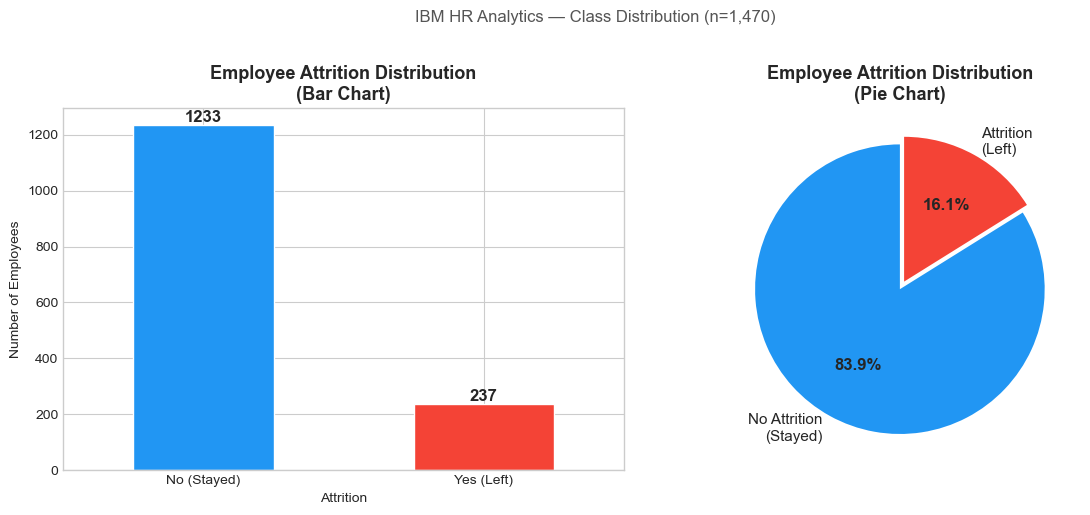

Note: Dataset is imbalanced — ~84% stayed, ~16% left.


In [75]:
# Check class distribution of target variable (Attrition)
print("Target Variable Distribution:")
print(df['Attrition'].value_counts())
print("\nPercentage:")
print(df['Attrition'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Visualise class distribution — Bar chart + Pie chart side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Bar chart ──
ax1 = axes[0]
df['Attrition'].value_counts().plot(kind='bar', ax=ax1,
    color=['#2196F3', '#F44336'], edgecolor='white')
ax1.set_title('Employee Attrition Distribution\n(Bar Chart)',
    fontsize=13, fontweight='bold')
ax1.set_xlabel('Attrition')
ax1.set_ylabel('Number of Employees')
ax1.set_xticklabels(['No (Stayed)', 'Yes (Left)'], rotation=0)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom', fontsize=12, fontweight='bold')

# ── Right: Pie chart ──
ax2 = axes[1]
counts = df['Attrition'].value_counts()
labels = ['No Attrition\n(Stayed)', 'Attrition\n(Left)']
colors = ['#2196F3', '#F44336']
explode = (0, 0.06)   # pop out the minority class slightly
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
ax2.set_title('Employee Attrition Distribution\n(Pie Chart)',
    fontsize=13, fontweight='bold')

plt.suptitle('IBM HR Analytics — Class Distribution (n=1,470)',
    fontsize=12, y=1.02, color='#555555')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Note: Dataset is imbalanced — ~84% stayed, ~16% left.")

## 3: Data Preprocessing

In [76]:
# 3.1 — Drop useless columns
# EmployeeCount  : all rows = 1 (no variation, useless)
# EmployeeNumber : just a row ID (not a feature)
# Over18         : all rows = 'Y' (no variation, useless)
# StandardHours  : all rows = 80 (no variation, useless)

columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=columns_to_drop)

print("Dropped columns:", columns_to_drop)
print("Dataset shape after dropping:", df.shape)  # Expected: (1470, 31)

Dropped columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Dataset shape after dropping: (1470, 31)


In [77]:
# 3.2 — Encode target variable
# Machine learning models need numbers, not text
# Yes (left) → 1
# No  (stayed) → 0

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Attrition encoded: Yes=1, No=0")
print(df['Attrition'].value_counts())

Attrition encoded: Yes=1, No=0
Attrition
0    1233
1     237
Name: count, dtype: int64


In [78]:
# 3.3 — Encode categorical columns
# Text columns like 'Department', 'Gender' must be converted to numbers
# Label Encoding assigns each unique value a unique integer

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_columns)

le = LabelEncoder()
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
    print(f"  Encoded: {col}")

print("\nAll categorical columns encoded successfully.")

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
  Encoded: BusinessTravel
  Encoded: Department
  Encoded: EducationField
  Encoded: Gender
  Encoded: JobRole
  Encoded: MaritalStatus
  Encoded: OverTime

All categorical columns encoded successfully.


In [79]:
# Step 3.4 — Separate features and target

X = df.drop('Attrition', axis=1)   # All columns except Attrition
y = df['Attrition']                 # Only the Attrition column

print("Features shape (X):", X.shape)   # Expected: (1470, 30)
print("Target shape   (y):", y.shape)   # Expected: (1470,)

Features shape (X): (1470, 30)
Target shape   (y): (1470,)


In [80]:
# Step 3.5 — Train / Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0], "rows (80%)")
print("Testing  set size:", X_test.shape[0],  "rows (20%)")
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

Training set size: 1176 rows (80%)
Testing  set size: 294 rows (20%)

Training class distribution:
Attrition
0    986
1    190
Name: count, dtype: int64

Testing class distribution:
Attrition
0    247
1     47
Name: count, dtype: int64


## 4: Build and Train the Decision Tree

In [81]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

# Train the model on the training data
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())
print("Number of features used:", dt_model.n_features_in_)

Decision Tree model trained successfully.
Tree depth: 5
Number of leaves: 25
Number of features used: 30


In [82]:
print("Effect of max_depth on model performance:")
print("-" * 55)

depth_values = [2, 3, 4, 5, 6, 8, 10, None]
best_depth = None
best_f1 = 0

for depth in depth_values:
    m = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    acc = accuracy_score(y_test, p)
    f1  = f1_score(y_test, p)
    label = str(depth) if depth else 'None (unlimited)'
    print(f"  max_depth={label:<16} → Accuracy: {acc*100:.2f}%  F1: {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_depth = depth

print("-" * 55)
print(f"Best max_depth by F1-Score: {best_depth}")
print("Conclusion: max_depth=5 balances accuracy and avoiding overfitting.")

Effect of max_depth on model performance:
-------------------------------------------------------
  max_depth=2                → Accuracy: 73.47%  F1: 0.4348
  max_depth=3                → Accuracy: 72.79%  F1: 0.4286
  max_depth=4                → Accuracy: 72.79%  F1: 0.3939
  max_depth=5                → Accuracy: 76.53%  F1: 0.4298
  max_depth=6                → Accuracy: 75.85%  F1: 0.4228
  max_depth=8                → Accuracy: 71.09%  F1: 0.3200
  max_depth=10               → Accuracy: 73.81%  F1: 0.2667
  max_depth=None (unlimited) → Accuracy: 75.85%  F1: 0.2828
-------------------------------------------------------
Best max_depth by F1-Score: 2
Conclusion: max_depth=5 balances accuracy and avoiding overfitting.


## 5: Visualise the Decision Tree

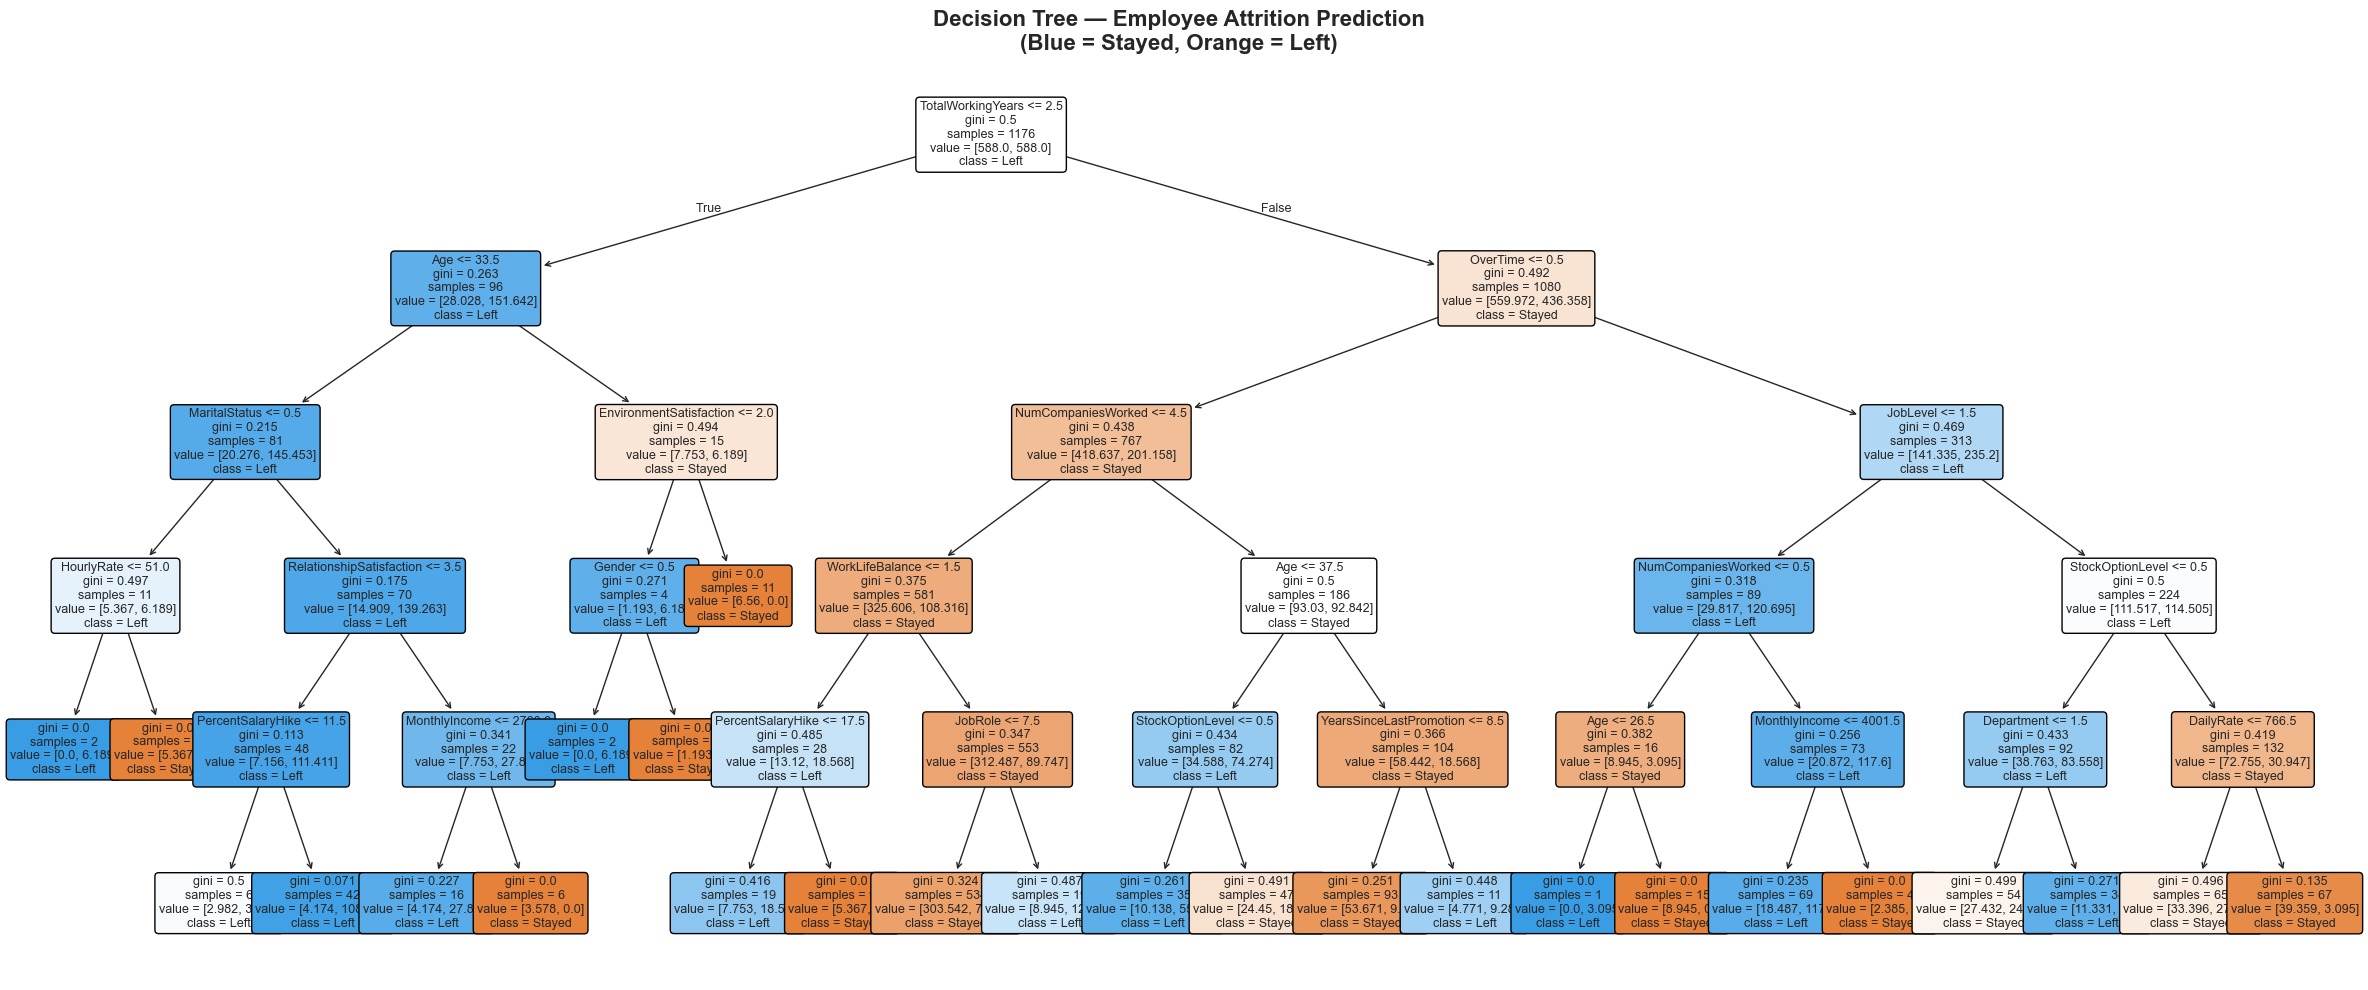

Tree visualisation saved as dt_tree_visualisation.png
This image shows every decision rule the model learned.


In [83]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),     # Show actual feature names
    class_names=['Stayed', 'Left'],        # Show readable class names
    filled=True,                           # Colour nodes by class
    rounded=True,                          # Rounded box corners
    fontsize=9,
    ax=ax
)
ax.set_title(
    'Decision Tree — Employee Attrition Prediction\n'
    '(Blue = Stayed, Orange = Left)',
    fontsize=16, fontweight='bold'
)
plt.tight_layout()
plt.savefig('dt_tree_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tree visualisation saved as dt_tree_visualisation.png")
print("This image shows every decision rule the model learned.")

In [84]:
# Print the top 3 levels of the tree as readable text rules
# This is useful to include in the report as a text explanation

print("Decision Tree Rules (top 3 levels):")
print("=" * 55)
tree_rules = export_text(
    dt_model,
    feature_names=X.columns.tolist(),
    max_depth=3
)
print(tree_rules)
print("Interpretation: Each line is a yes/no question the model asks.")
print("'class: 0' means predicted Stayed, 'class: 1' means predicted Left.")

Decision Tree Rules (top 3 levels):
|--- TotalWorkingYears <= 2.50
|   |--- Age <= 33.50
|   |   |--- MaritalStatus <= 0.50
|   |   |   |--- HourlyRate <= 51.00
|   |   |   |   |--- class: 1
|   |   |   |--- HourlyRate >  51.00
|   |   |   |   |--- class: 0
|   |   |--- MaritalStatus >  0.50
|   |   |   |--- RelationshipSatisfaction <= 3.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- RelationshipSatisfaction >  3.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- Age >  33.50
|   |   |--- EnvironmentSatisfaction <= 2.00
|   |   |   |--- Gender <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Gender >  0.50
|   |   |   |   |--- class: 0
|   |   |--- EnvironmentSatisfaction >  2.00
|   |   |   |--- class: 0
|--- TotalWorkingYears >  2.50
|   |--- OverTime <= 0.50
|   |   |--- NumCompaniesWorked <= 4.50
|   |   |   |--- WorkLifeBalance <= 1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- WorkLifeBalance >  1.50
|   |   |   |   |--

## 6: Make Predictions and Evaluate

In [85]:
# Predict on unseen test data
y_pred       = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]  # For ROC curve

print("Predictions made on test set.")
print("Predicted Attrition=Yes:", sum(y_pred == 1))
print("Predicted Attrition=No :", sum(y_pred == 0))

Predictions made on test set.
Predicted Attrition=Yes: 74
Predicted Attrition=No : 220


In [86]:
# Calculate all evaluation metrics
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
error_rate = 1 - acc

print("=" * 55)
print("  DECISION TREE — EVALUATION RESULTS")
print("=" * 55)
print(f"  Accuracy   : {acc * 100:.2f}%")
print(f"  Error Rate : {error_rate * 100:.2f}%")
print("=" * 55)
print("\nFull Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['No Attrition (Stayed)', 'Attrition (Left)']
))

  DECISION TREE — EVALUATION RESULTS
  Accuracy   : 76.53%
  Error Rate : 23.47%

Full Classification Report:
                       precision    recall  f1-score   support

No Attrition (Stayed)       0.90      0.81      0.85       247
     Attrition (Left)       0.35      0.55      0.43        47

             accuracy                           0.77       294
            macro avg       0.63      0.68      0.64       294
         weighted avg       0.82      0.77      0.78       294



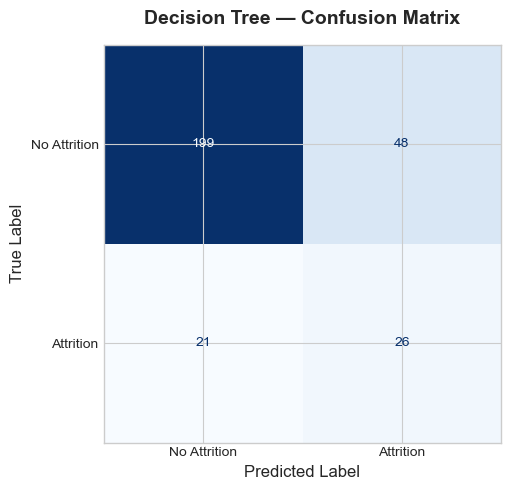

True Negatives  (correctly predicted stayed) : 199
False Positives (predicted left, stayed)     : 48
False Negatives (predicted stayed, left)     : 21
True Positives  (correctly predicted left)   : 26


In [87]:
# ─────────────────────────────────────────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Attrition', 'Attrition']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Decision Tree — Confusion Matrix',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted stayed) : {tn}")
print(f"False Positives (predicted left, stayed)     : {fp}")
print(f"False Negatives (predicted stayed, left)     : {fn}")
print(f"True Positives  (correctly predicted left)   : {tp}")

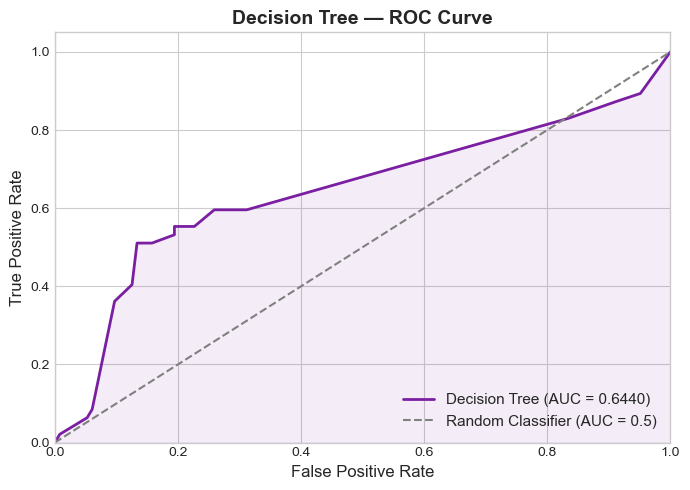

AUC Score: 0.6440


In [88]:
# ─────────────────────────────────────────────────────────────────
# ROC CURVE AND AUC SCORE
# ─────────────────────────────────────────────────────────────────

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#7B1FA2', lw=2,
        label=f'Decision Tree (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        lw=1.5, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#7B1FA2')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Decision Tree — ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('dt_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC Score: {roc_auc:.4f}")

## 7: Feature Importance

Top 15 features used in the Decision Tree:
---------------------------------------------
   1. TotalWorkingYears              0.1995
   2. OverTime                       0.1677
   3. Age                            0.1073
   4. StockOptionLevel               0.1016
   5. NumCompaniesWorked             0.0955
   6. JobLevel                       0.0626
   7. MonthlyIncome                  0.0333
   8. Department                     0.0315
   9. WorkLifeBalance                0.0307
  10. DailyRate                      0.0291
  11. PercentSalaryHike              0.0271
  12. YearsSinceLastPromotion        0.0240
  13. JobRole                        0.0229
  14. HourlyRate                     0.0229
  15. EnvironmentSatisfaction        0.0194


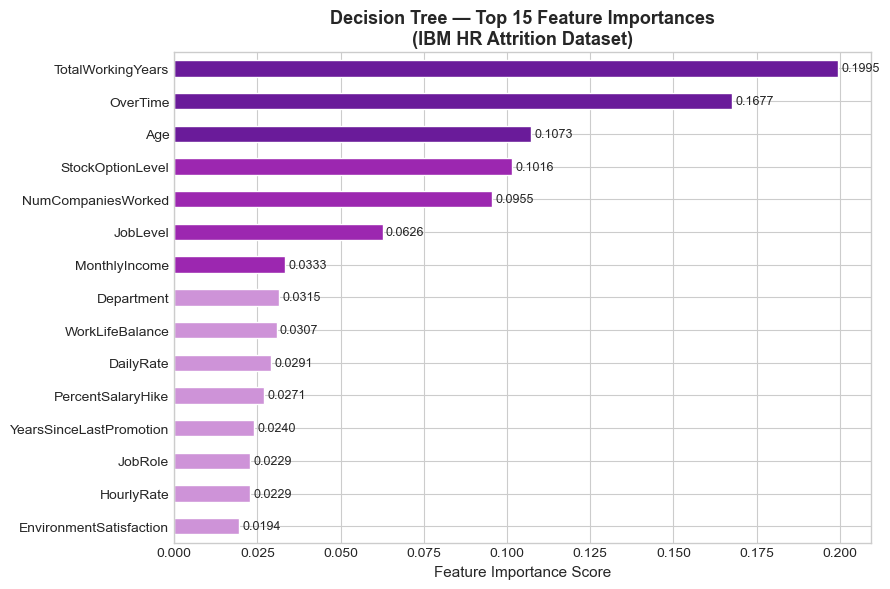

In [89]:
# Extract feature importance from the trained model
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Show top 15 features
print("Top 15 features used in the Decision Tree:")
print("-" * 45)
for i, (feat, score) in enumerate(feature_importance.head(15).items(), 1):
    print(f"  {i:2}. {feat:<30} {score:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#6A1B9A' if i < 3 else '#9C27B0' if i < 7 else '#CE93D8'
          for i in range(15)]
feature_importance.head(15).plot(kind='barh', ax=ax,
    color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_title(
    'Decision Tree — Top 15 Feature Importances\n(IBM HR Attrition Dataset)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Feature Importance Score', fontsize=11)
for bar, val in zip(ax.patches, feature_importance.head(15)):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8: Full Results Summary

In [90]:
import csv
from datetime import datetime

# Recalculate AUC to make sure it is current
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc     = auc(fpr, tpr)

# ── Print results summary to screen ──
print("=" * 55)
print("   DECISION TREE — COMPLETE RESULTS SUMMARY")
print("   Copy these into the group comparison table")
print("=" * 55)
print(f"   Algorithm    : Decision Tree Classifier")
print(f"   criterion    : gini")
print(f"   max_depth    : 5")
print(f"   class_weight : balanced")
print(f"   Train size   : {len(X_train)} samples (80%)")
print(f"   Test size    : {len(X_test)} samples (20%)")
print("-" * 55)
print(f"   Accuracy     : {acc*100:.2f}%")
print(f"   Error Rate   : {error_rate*100:.2f}%")
print(f"   Precision    : {precision:.4f}")
print(f"   Recall       : {recall:.4f}")
print(f"   F1-Score     : {f1:.4f}")
print(f"   AUC Score    : {roc_auc:.4f}")
print("=" * 55)

# ── Auto-save metrics to CSV ──

csv_filename = 'Decision_Tree_Metrics.csv'

metrics_row = {
    'Model':           'Decision Tree',
    'Algorithm':       'DecisionTree Classifier',
    'Accuracy (%)':    round(acc * 100, 2),
    'F1 Score (%)':    round(f1 * 100, 2),
    'Precision (%)':   round(precision * 100, 2),
    'Recall (%)':      round(recall * 100, 2),
    'ROC-AUC (%)':     round(roc_auc * 100, 2),
    'Threshold':       0.5,
    'Class Weights':   'balanced',
    'Iterations':      'N/A',
    'Best Iteration':  'N/A',
    'Train Samples':   len(X_train),
    'Test Samples':    len(X_test),
    'Features Used':   X_train.shape[1],
}

with open(csv_filename, 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=metrics_row.keys())
    writer.writeheader()
    writer.writerow(metrics_row)

print(f"\nFiles saved automatically:")
print(f"  1. class_distribution.png")
print(f"  2. dt_tree_visualisation.png")
print(f"  3. dt_confusion_matrix.png")
print(f"  4. dt_roc_curve.png")
print(f"  5. dt_feature_importance.png")
print(f"  6. {csv_filename}")

   DECISION TREE — COMPLETE RESULTS SUMMARY
   Copy these into the group comparison table
   Algorithm    : Decision Tree Classifier
   criterion    : gini
   max_depth    : 5
   class_weight : balanced
   Train size   : 1176 samples (80%)
   Test size    : 294 samples (20%)
-------------------------------------------------------
   Accuracy     : 76.53%
   Error Rate   : 23.47%
   Precision    : 0.3514
   Recall       : 0.5532
   F1-Score     : 0.4298
   AUC Score    : 0.6440

Files saved automatically:
  1. class_distribution.png
  2. dt_tree_visualisation.png
  3. dt_confusion_matrix.png
  4. dt_roc_curve.png
  5. dt_feature_importance.png
  6. Decision_Tree_Metrics.csv


## 9: Critical Analysis

In [91]:
print("Comparing training accuracy vs test accuracy (overfitting check):")
print("-" * 60)

for depth in [3, 5, 10, None]:
    m = DecisionTreeClassifier(
        criterion='gini', max_depth=depth,
        class_weight='balanced', random_state=42
    )
    m.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, m.predict(X_train))
    test_acc  = accuracy_score(y_test,  m.predict(X_test))
    gap = train_acc - test_acc
    label = str(depth) if depth else 'None'
    print(f"  max_depth={label:<5} Train: {train_acc*100:.1f}%  "
          f"Test: {test_acc*100:.1f}%  Gap: {gap*100:.1f}%")

print("-" * 60)
print("Conclusion: Unlimited depth overfits — train accuracy is very high")
print("but test accuracy is lower. max_depth=5 gives the best balance.")

Comparing training accuracy vs test accuracy (overfitting check):
------------------------------------------------------------
  max_depth=3     Train: 71.3%  Test: 72.8%  Gap: -1.5%
  max_depth=5     Train: 85.2%  Test: 76.5%  Gap: 8.7%
  max_depth=10    Train: 97.4%  Test: 73.8%  Gap: 23.6%
  max_depth=None  Train: 100.0%  Test: 75.9%  Gap: 24.1%
------------------------------------------------------------
Conclusion: Unlimited depth overfits — train accuracy is very high
but test accuracy is lower. max_depth=5 gives the best balance.
